1) Problem Statement
This project helps us understand how student performance is affected by other variables Gender, Ethinicity, Parental Level Of Education and Test Preparation Course

Import Data and Required Packages

Import Pandas Numpy Matplotlib Seaborn and warings library

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Import data as pandas dataframe

In [3]:
df=pd.read_csv("data/StudentsPerformance.csv")

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Dataset Information¶

gender : sex of students -> (Male/female)
race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
lunch : having lunch before test (standard or free/reduced)
test preparation course : complete or not complete before test
math score
reading score
writing score

Data Checks to perform

Steps :
Check Missing values
Check Duplicates
Check data type
Check the number of unique values of each column
Check statistics of data set
Check various categories present in the different categorical column

In [5]:
#Checking Missing Values
df.isnull().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [6]:
# Checking Duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
#Check Null and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


Gender, race_ethnicity, parental_level_of_education, lunch, test_preparaton_course are Object Dtype and Math_score, reading_score, writing_score are int Dtype.

In [7]:
#Checking the No.of Unique Values in the dataset
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [8]:
df.nunique().sum()

np.int64(247)

In [13]:
#Checking Stat of Data
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Insights :

From above Statistics
Mean for math_score, reading_score, writing_score close to each other - between 66 to 68.
Standard Deviation is also close to each other - between 14 to 15.
Minimum value is 0 for math_score and Maximum Value is 100 for all three.

In [9]:
print("Categories in 'Gender' Variable:    ",end=" ")
print(df['gender'].unique())
print("Categories in 'race/ethnicity' Variable:    ",end=" ")
print(df['race/ethnicity'].unique())
print("Categories in 'parental level of education' Variable:    ",end=" ")
print(df['parental level of education'].unique())
print("Categories in 'lunch' Variable:    ",end=" ")
print(df['lunch'].unique())
print("Categories in 'test preparation course' Variable:    ",end=" ")
print(df['test preparation course'].unique())

Categories in 'Gender' Variable:     ['female' 'male']
Categories in 'race/ethnicity' Variable:     ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' Variable:     ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' Variable:     ['standard' 'free/reduced']
Categories in 'test preparation course' Variable:     ['none' 'completed']


In [10]:
numerical_features=[feature for feature in df.columns if df[feature].dtype != 'O']
Categorical_features=[feature for feature in df.columns if df[feature].dtype == 'O']


print("There are {} numerical features. those are {}".format(len(numerical_features),numerical_features))
print("There are {} categorical features . those are {}".format(len(Categorical_features),Categorical_features))

There are 3 numerical features. those are ['math score', 'reading score', 'writing score']
There are 5 categorical features . those are ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


Adding Columns for Total Score and Average

In [13]:
df['total_score']=df['math score']+df['reading score']+df['writing score']
df['average']=df['total_score']/len(numerical_features)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


No.of Students with Full Marks in math_score, reading_score, writing_score

In [20]:
math_full=df[df['math score']==100]['average'].count()
reading_full=df[df['reading score']==100]['average'].count()
writing_full=df[df['writing score']==100]['average'].count()

print("Number of Students with Full marks in Math_score : {}".format(math_full))
print("Number of Students with Full marks in reading_score : {}".format(reading_full))
print("Number of Students with Full marks in writing_score : {}".format(writing_full))

Number of Students with Full marks in Math_score : 7
Number of Students with Full marks in reading_score : 17
Number of Students with Full marks in writing_score : 14


Data Visualization

<Axes: xlabel='average', ylabel='Count'>

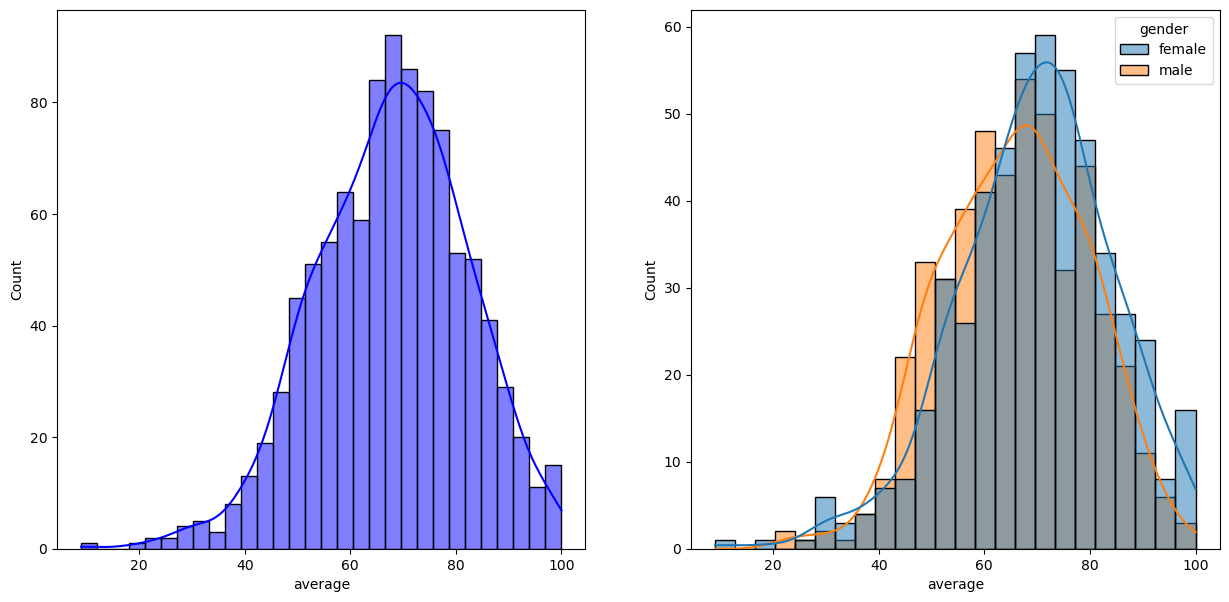

In [24]:
plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='blue',)
plt.subplot(122)
sns.histplot(df,x='average',kde=True,hue='gender')


<Axes: xlabel='total_score', ylabel='Count'>

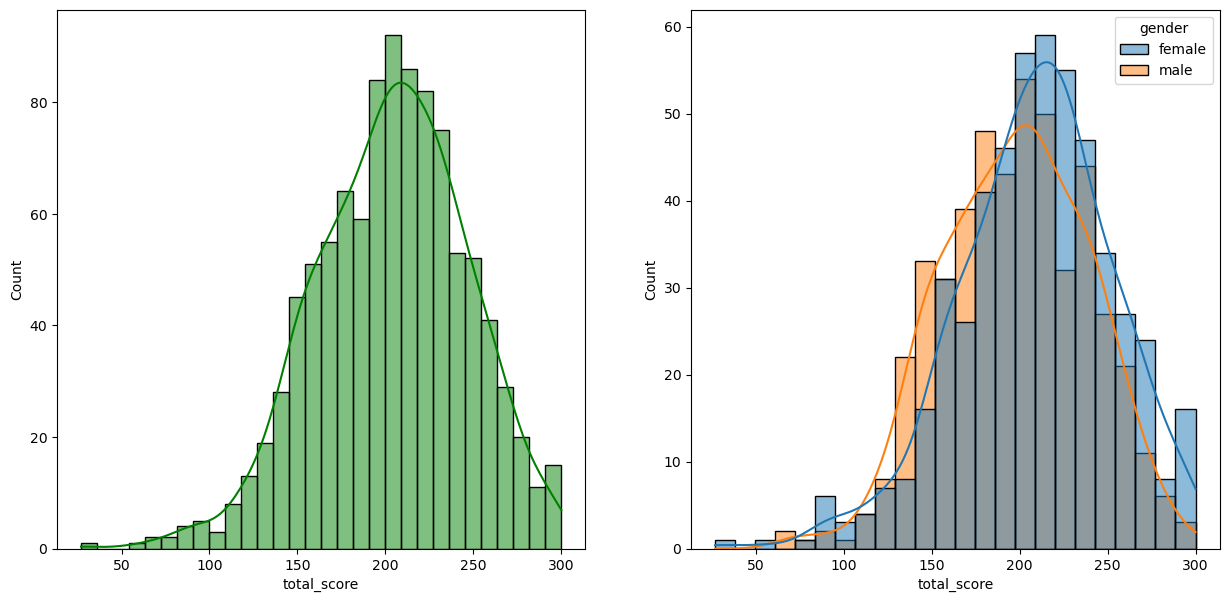

In [26]:
plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='green')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')

Insights : Female Students perform well in exam then male students.

<Axes: xlabel='average', ylabel='Count'>

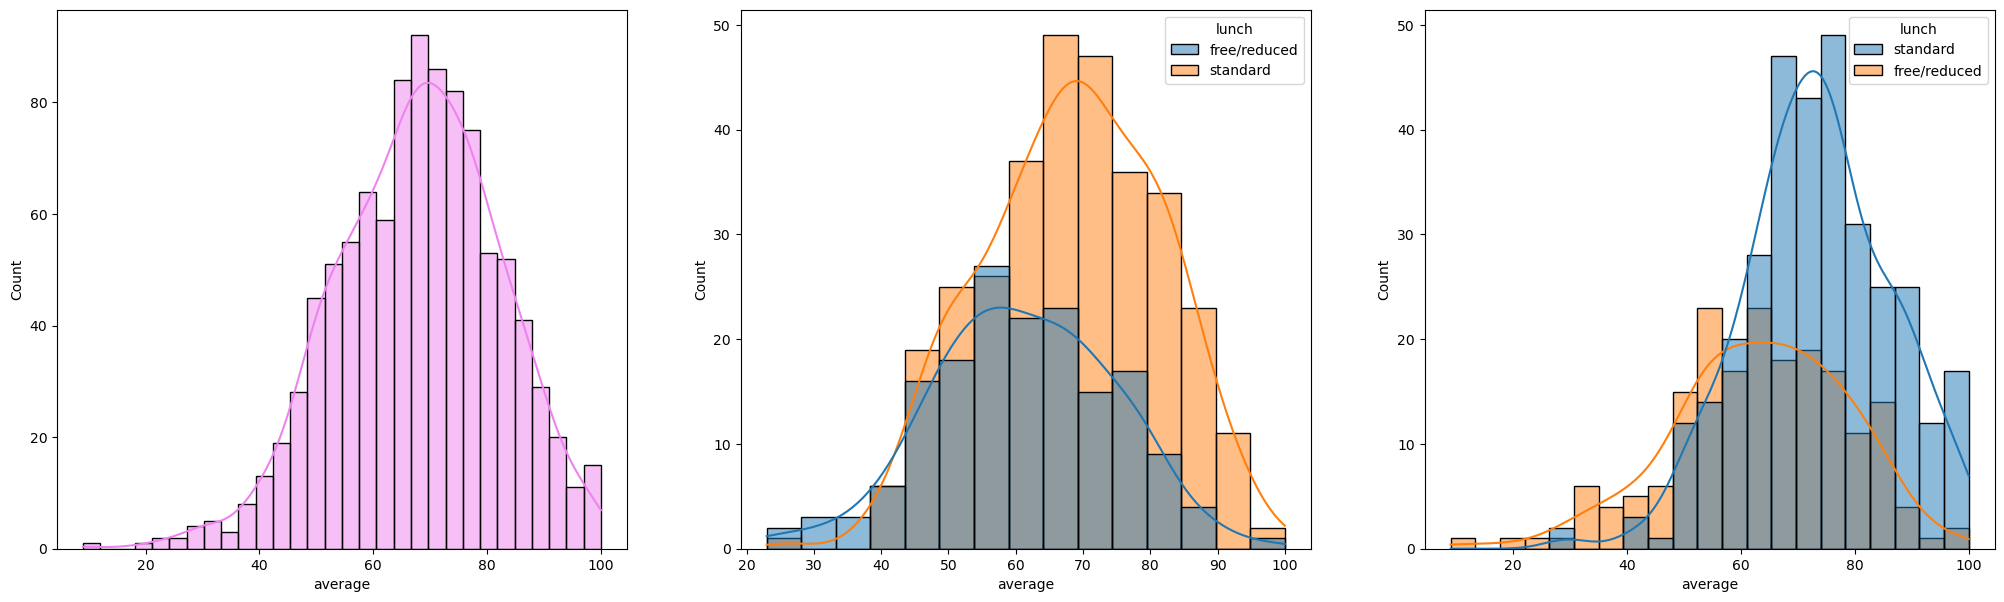

In [29]:
plt.subplots(1,3,figsize=(25,7))
plt.subplot(1,3,1)
sns.histplot(data=df,x='average',bins=30,kde=True,color='violet')
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')

Insight :

Standard lunch helps to perform well in exams.
Standard lunch helps to perform well in exams for both genders (Male and female).

<Axes: xlabel='average', ylabel='Count'>

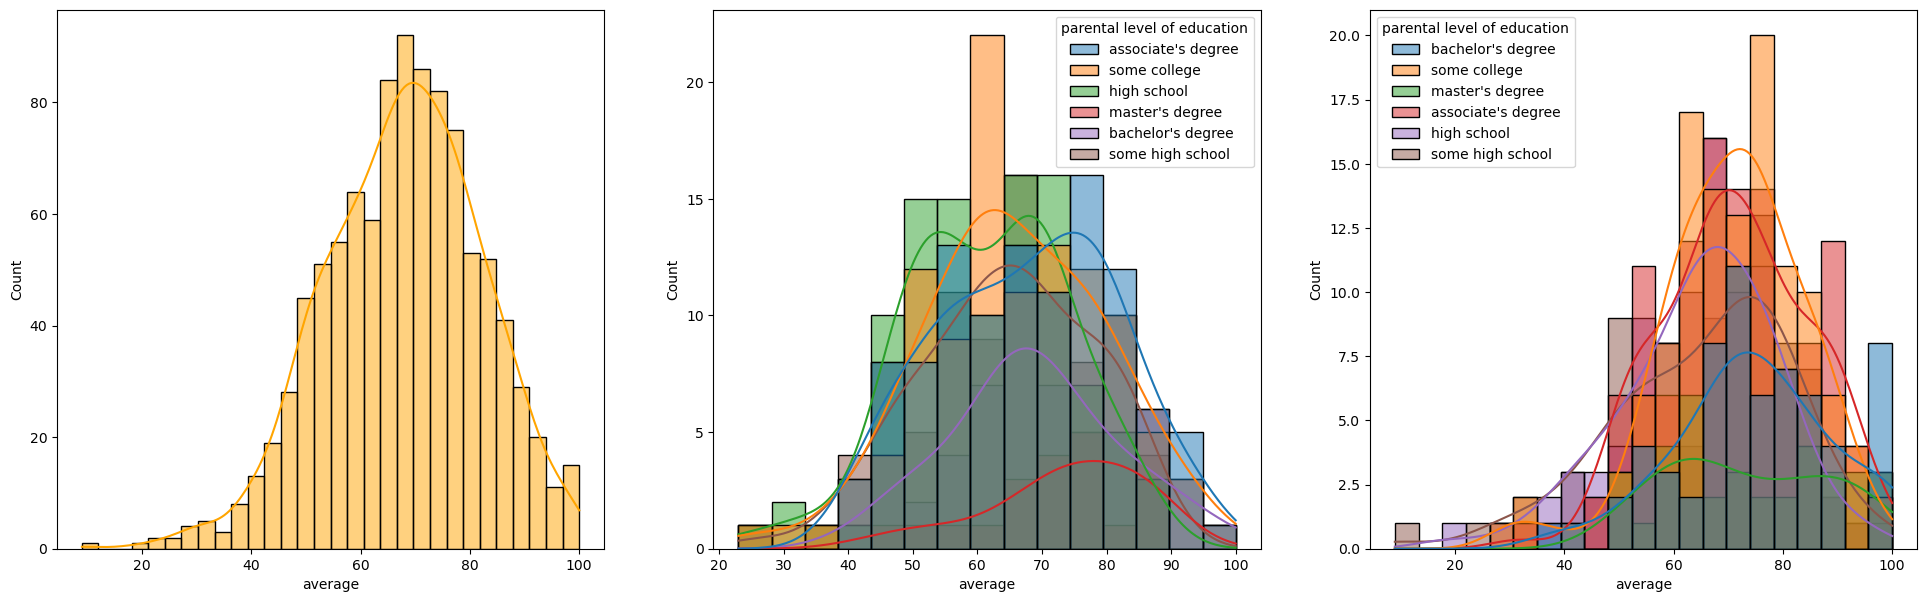

In [32]:
plt.subplots(1,3,figsize=(24,7))
plt.subplot(131)
sns.histplot(data=df,x='average',bins=30,kde=True,color='orange')
plt.subplot(132)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental level of education')
plt.subplot(133)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental level of education')

Insights :

In general, Parents education dont help student to perform well in exam

When you observe in Chart 2, we can say that whose education is of Associate's degree or master's degree their child tend to perform well in exams.

When you observe in chart 3, we can say that for female students has no effect with parental education.

<Axes: xlabel='average', ylabel='Count'>

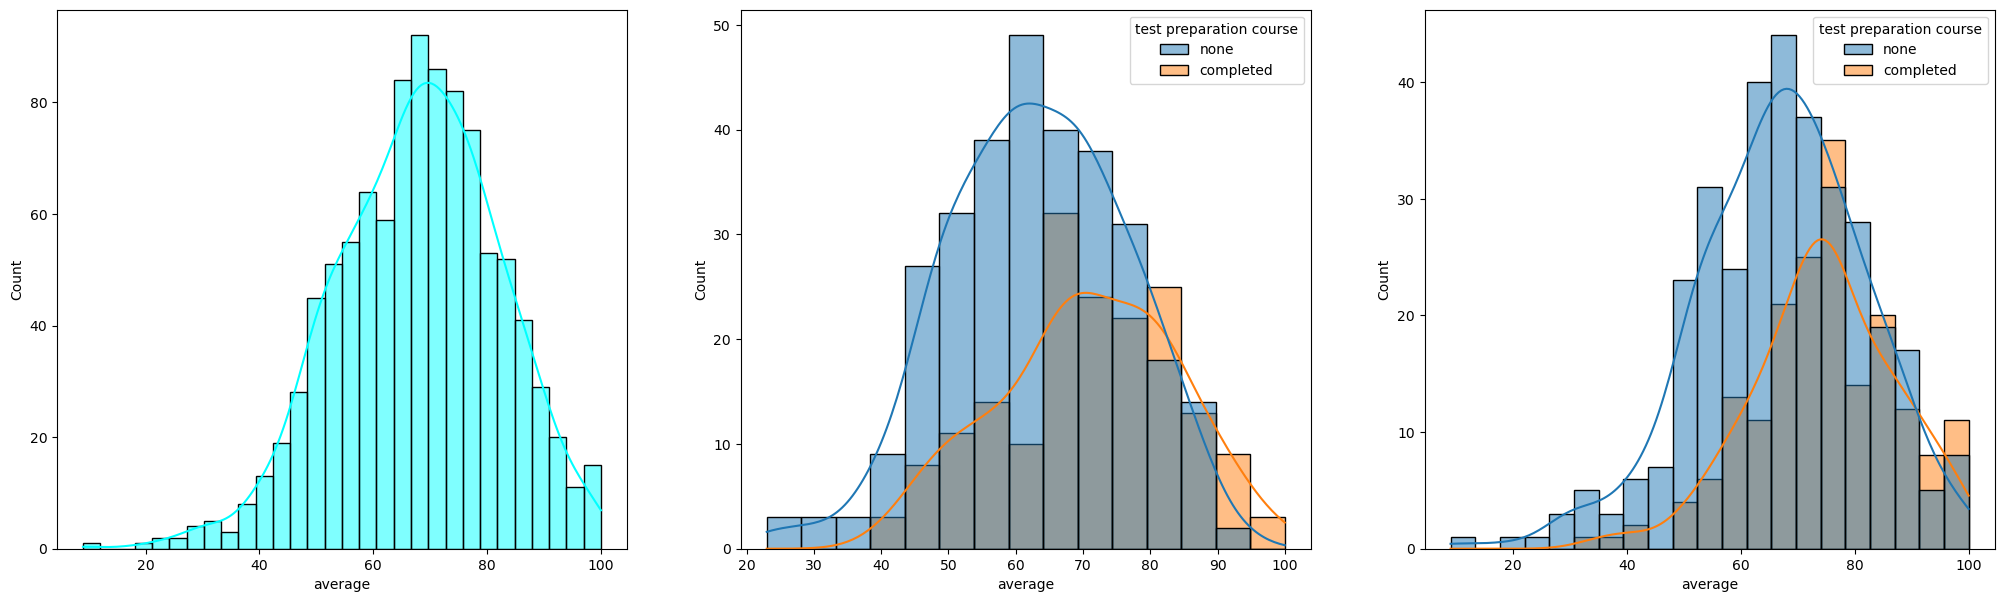

In [36]:
plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
sns.histplot(data=df,x='average',bins=30,kde=True,color='cyan')
plt.subplot(132)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='test preparation course')
plt.subplot(133)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='test preparation course')

Insight:

Students performing well in exam who are all completing the test prepartion course.

<Axes: xlabel='average', ylabel='Count'>

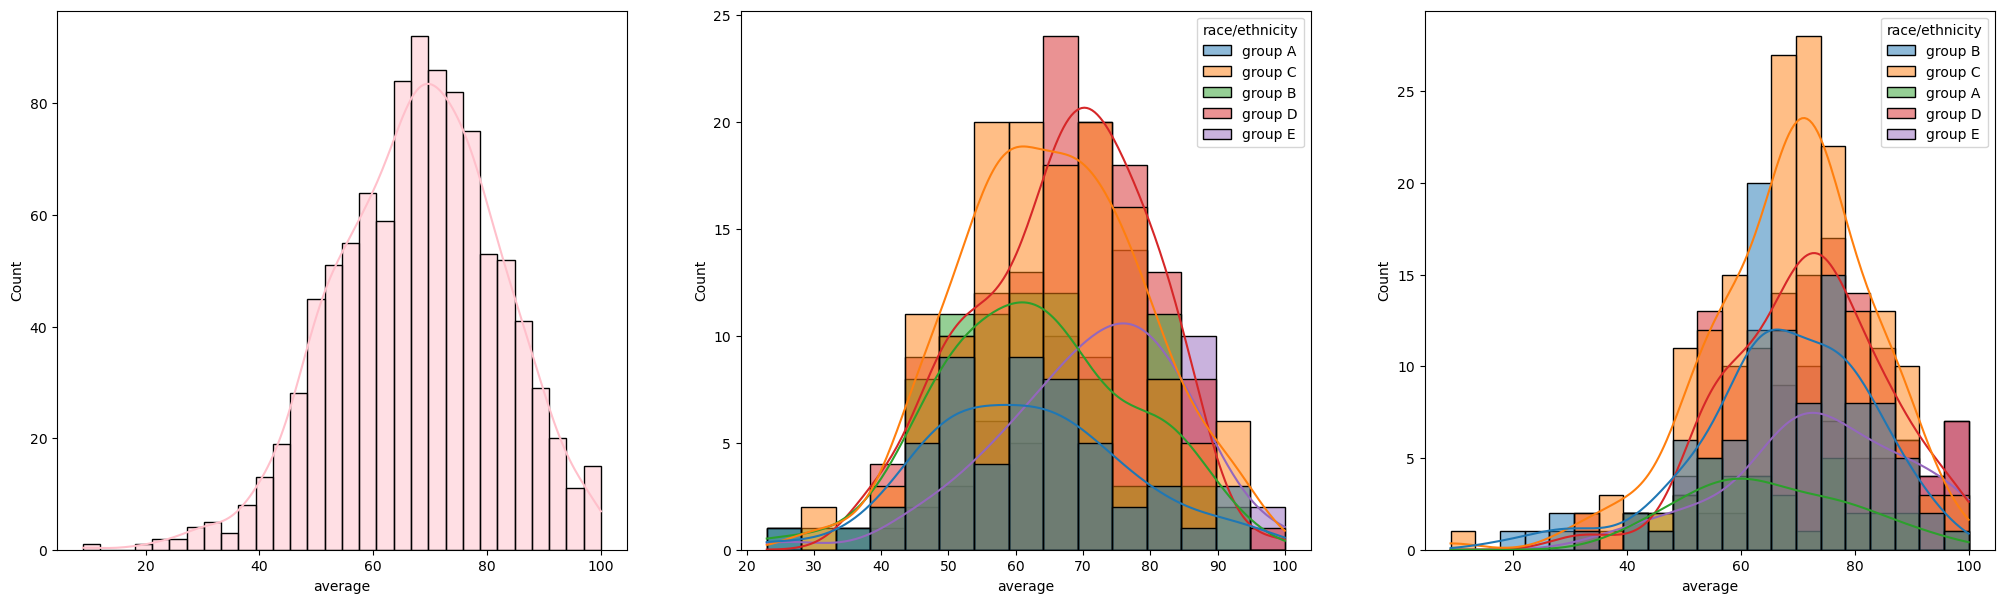

In [39]:
plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
sns.histplot(data=df,x='average',bins=30,kde=True,color='pink')
plt.subplot(132)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race/ethnicity')
plt.subplot(133)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race/ethnicity')

Insights: Students from Group B and Group C tends to perform poorly in exams.

Maximum score of students in all three subjects (Math score, Reading score, Writing score)

<Axes: title={'center': 'Writing Score'}, ylabel='writing score'>

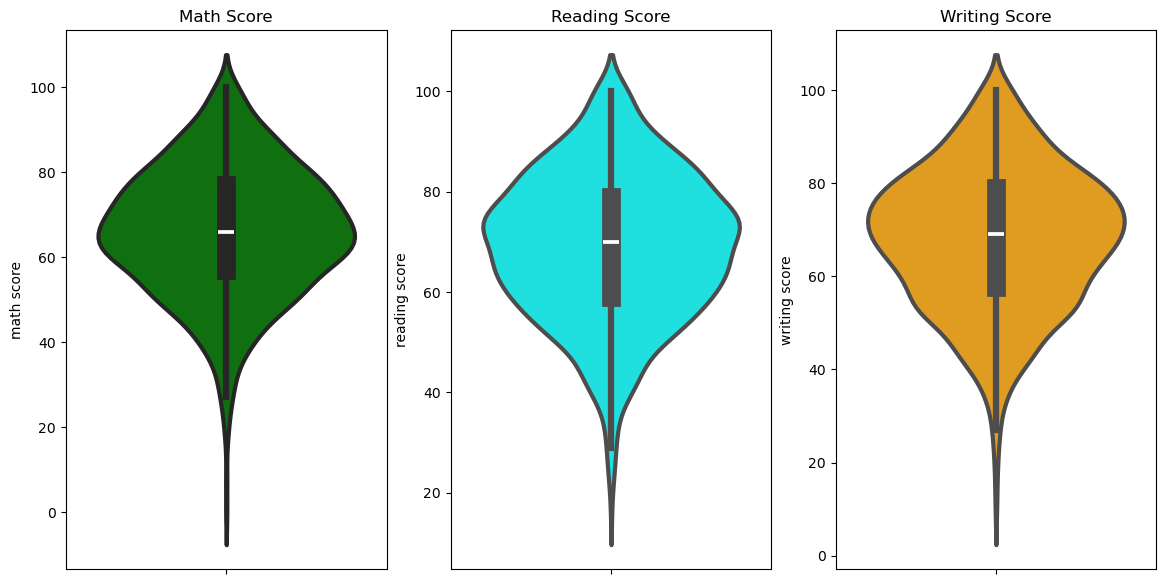

In [42]:
plt.figure(figsize=(24,7))
plt.subplot(151)
plt.title("Math Score")
sns.violinplot(y='math score',data=df,color='green',linewidth=3)
plt.subplot(152)
plt.title("Reading Score")
sns.violinplot(y='reading score',data=df,color='cyan',linewidth=3)
plt.subplot(153)
plt.title("Writing Score")
sns.violinplot(y='writing score',data=df,color='orange',linewidth=3)

(np.float64(-1.25), np.float64(1.25), np.float64(-1.25), np.float64(1.25))

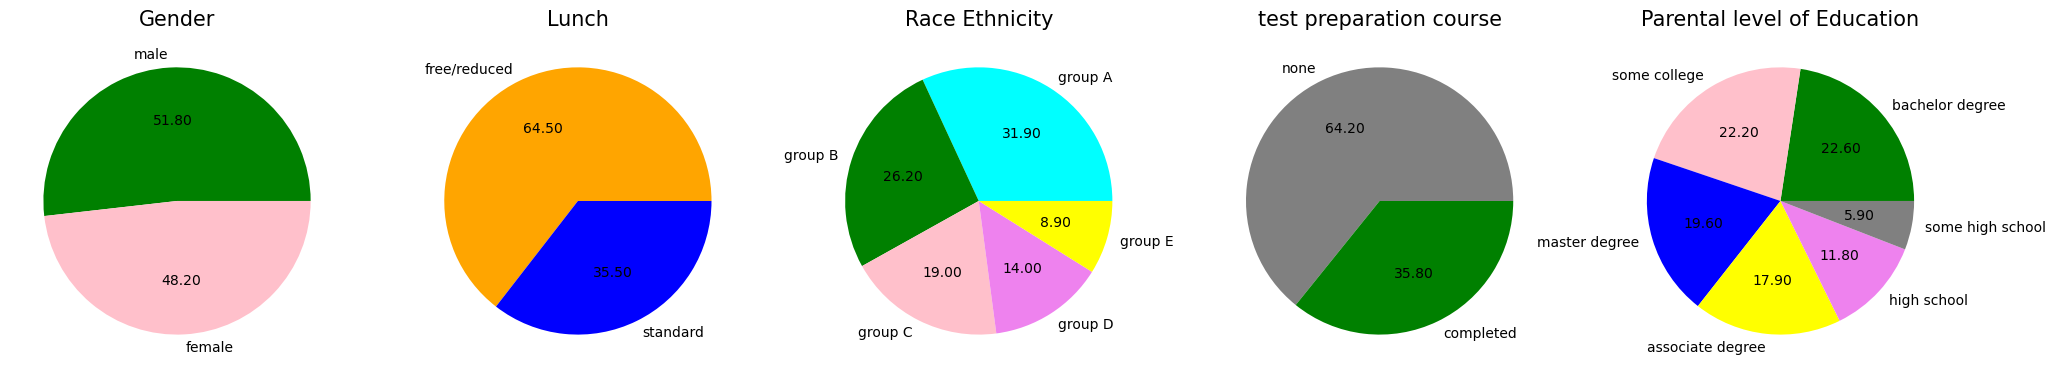

In [43]:
plt.rcParams['figure.figsize']=(25,12)

plt.subplot(151)
size=df['gender'].value_counts()
labels=['male','female']
colors=['green','pink']

plt.pie(size,colors=colors,labels=labels,autopct='%.2f')
plt.title('Gender',fontsize=15)
plt.axis('off')

plt.subplot(152)
size=df['lunch'].value_counts()
labels=['free/reduced','standard']
colors=['orange','blue']

plt.pie(size,colors=colors,labels=labels,autopct='%.2f')
plt.title('Lunch',fontsize=15)
plt.axis('off')

plt.subplot(153)
size=df['race/ethnicity'].value_counts()
labels=['group A','group B','group C','group D','group E']
colors=['cyan','green','pink','violet','yellow']
plt.pie(size,colors=colors,labels=labels,autopct='%.2f')
plt.title('Race Ethnicity',fontsize=15)
plt.axis('off')


plt.subplot(154)
size=df['test preparation course'].value_counts()
labels=['none','completed']
colors=['grey','green']
plt.pie(size,colors=colors,labels=labels,autopct='%.2f')
plt.title('test preparation course',fontsize=15)
plt.axis('off')

plt.subplot(155)
size=df['parental level of education'].value_counts()
labels=['bachelor degree','some college','master degree','associate degree','high school','some high school']
colors=['green','pink','blue','yellow','violet','grey']
plt.pie(size,colors=colors,labels=labels,autopct='%.2f')
plt.title('Parental level of Education',fontsize=15)
plt.axis('off')


Insights:

No.of male and female students are almost equal

No.of students who have standard lunch are greater

No.of Students are greater in Group B race ethnicity

No.of Students who are not enrolled in test preparation course

No.of Students whose parental level of education is greater for 'Some college' and followed by 'bachelor degree'

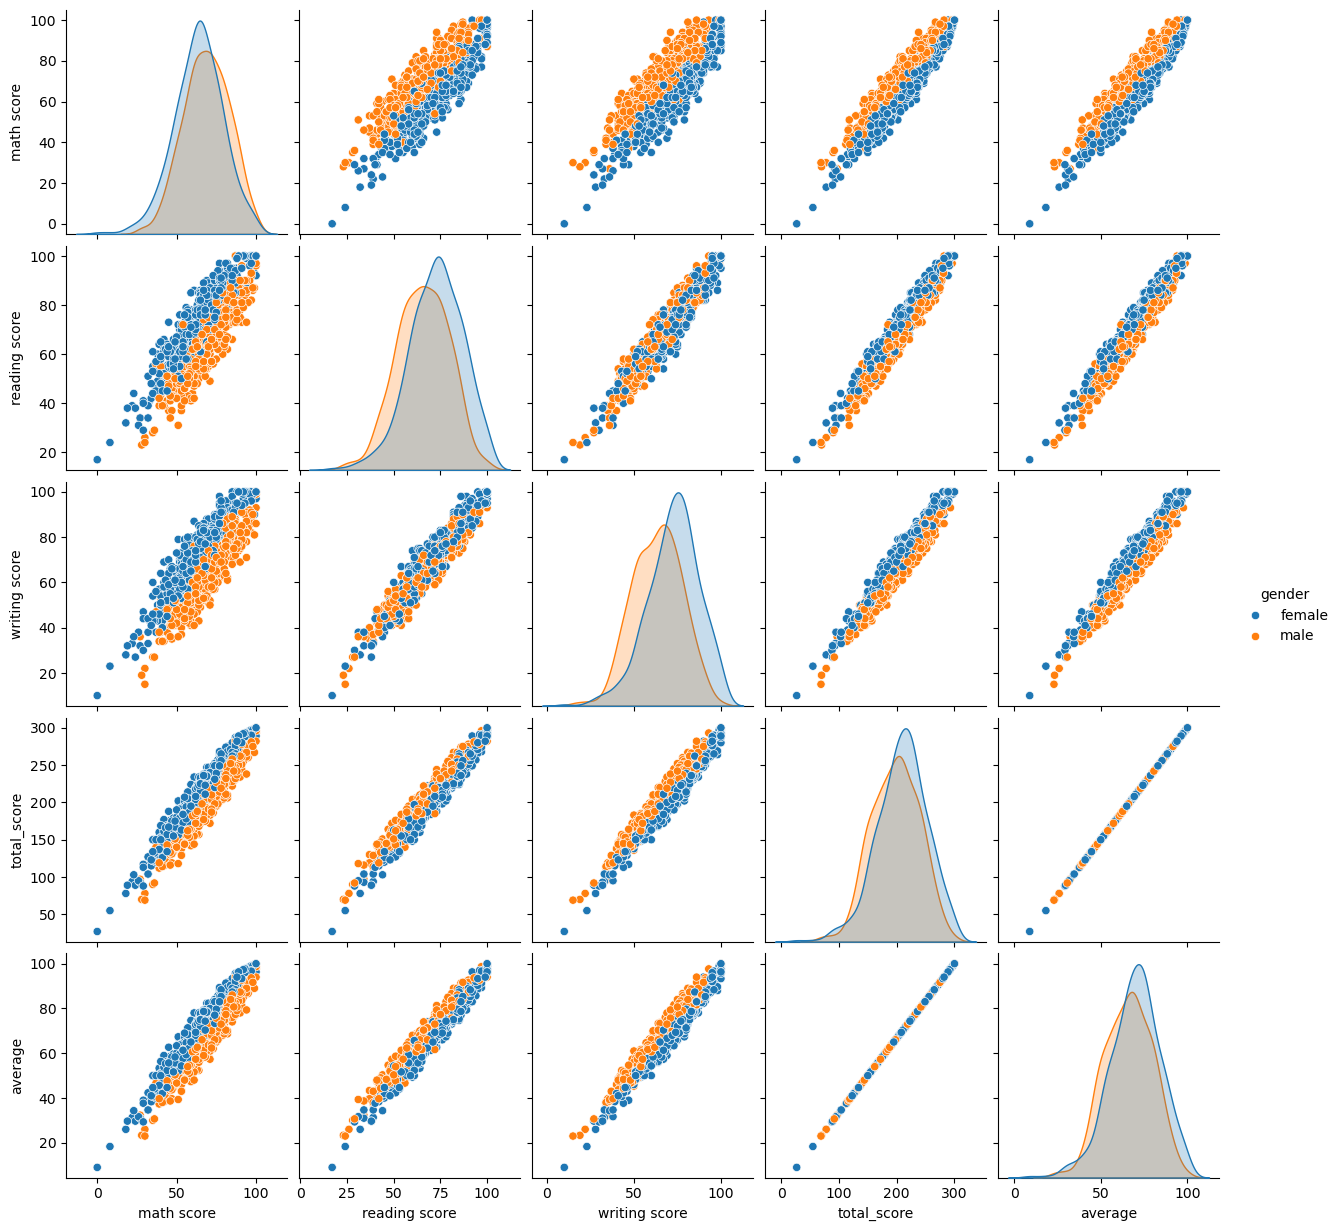

In [44]:
sns.pairplot(df,hue='gender')